## Library Imports

In [69]:
import sys
import importlib
import os.path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.optimize import brentq

# Add the current directory to the path to find local modules
sys.path.append('.')
import BTSSlayers as btss

# Suppress unnecessary warnings for a cleaner output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## Load & Prepare Data

In [70]:
# Read a large set of 491 translation sessions from the TPR-DB
GD = pd.read_csv('sorted.gaze.clean.txt', sep="\t", dtype=None)

# read the Tables from the TPR-DB
BTSS1 = btss.readBTSSsessions(GD['Study-Session'], layers = ['au1', 'fd','kd'], verbose=0)

# rename for easier use
AUdf_old = BTSS1['au1']
FDdf = BTSS1['fd'] 
KDdf_old = BTSS1['kd']
print("AUs:", AUdf_old.shape, "FDs:", FDdf.shape, "KDs:", KDdf_old.shape)

AUs: (263719, 73) FDs: (999492, 22) KDs: (564649, 25)


In [71]:
KDdf_old['StudySession'] = KDdf_old['Study'] + '-' + KDdf_old['Session']
KDdf_old.shape

(564649, 26)

In [76]:
KDdf = KDdf_old.copy() 
KDdf = KDdf.sort_values(by=['StudySession', 'Time'])
KDdf['IKI'] = KDdf.groupby('StudySession')['Time'].diff()
KDdf_iki = KDdf.dropna(subset=['IKI']).copy()
KDdf_iki['LogIKI'] = np.log(KDdf_iki.IKI)

# Calculate LogPUB for all StudySessions ---
AUdf_logpub = AUdf_old.copy()
AUdf_logpub = AUdf_logpub.drop_duplicates(subset=['StudySession'])

# Calculate the LogPUB (using the logic PUB/3)
AUdf_logpub['PUB1'] = AUdf_logpub['PUB'] / 3
AUdf_logpub['LogPUB'] = np.log(AUdf_logpub.PUB1)
AUdf_logpub['KBI1'] = AUdf_logpub['KBI'] / 2
AUdf_logpub['LogKBI'] = np.log(AUdf_logpub.KBI1)
AUdf_logpub_final = AUdf_logpub[['StudySession', 'LogPUB','LogKBI']].copy()
print("LogPUB,LogKBI calculation complete for all sessions.")

LogPUB,LogKBI calculation complete for all sessions.


## Gaussian Mixture Model(GMM) Component Analysis (AIC/BIC)

Starting GMM component analysis per session (Calculating BIC & AIC optimal Ns).
  Processed 50/490 sessions...
  Processed 100/490 sessions...
  Processed 150/490 sessions...
  Processed 200/490 sessions...
  Processed 250/490 sessions...
  Processed 300/490 sessions...
  Processed 350/490 sessions...
  Processed 400/490 sessions...
  Processed 450/490 sessions...
Analysis complete in 11.40 seconds.

--- Summary Results ---
   StudySession  Optimal_GMM_Components_BIC  Optimal_GMM_Components_AIC
0  ACS08-P01_T3                           2                           3
1  ACS08-P01_T4                           2                           3
2  ACS08-P02_T4                           3                           3
3  ACS08-P03_T1                           3                           3
4  ACS08-P03_T2                           3                           3

--- Summary of Optimal Components ---
Most frequent BIC-optimal component count: 3
Most frequent AIC-optimal component count: 3


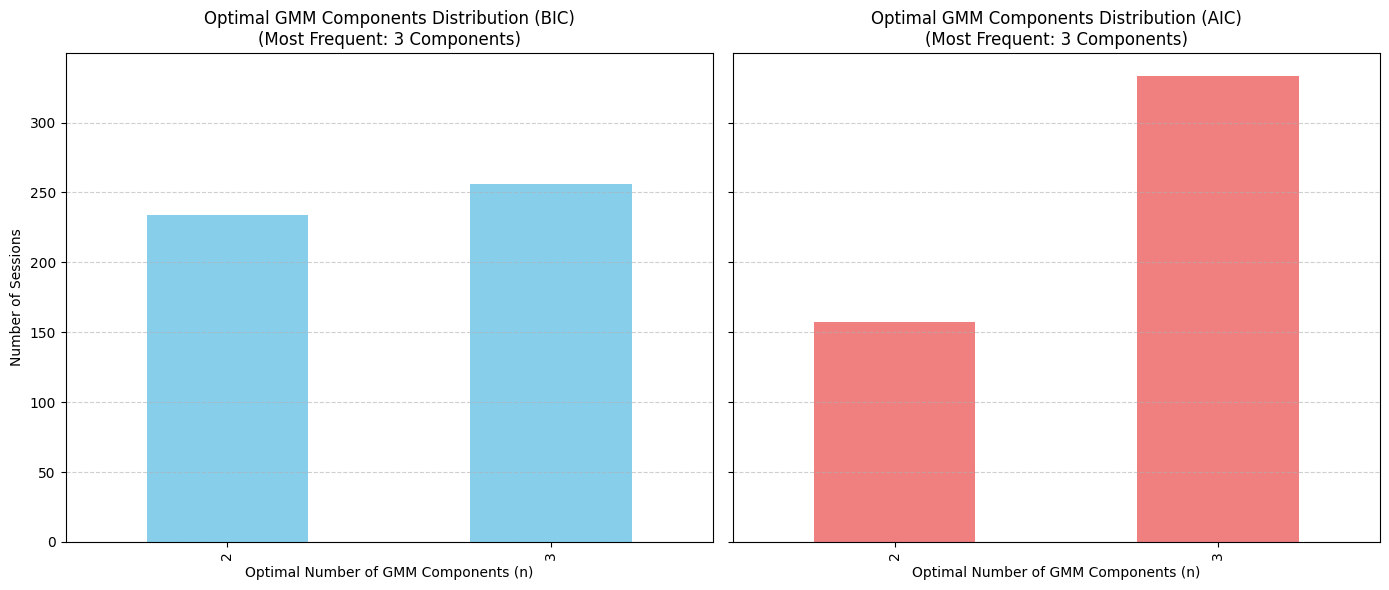

In [77]:
# --- AIC/BIC Optimization Function ---
def find_optimal_gmm_components_aic_bic(data_series, max_components=3):
    """
    Fits GMMs (1 to max_components) and returns the optimal component count
    based on the minimum BIC score and the minimum AIC score.
    """
    X = data_series.dropna().values.reshape(-1, 1)

    if len(X) < 2:
        return np.nan, np.nan # Return optimal N for BIC, AIC
    
    n_test = min(max_components, len(X))
    if n_test < 1:
        return np.nan, np.nan

    n_components = np.arange(1, n_test + 1)
    
    bic_scores = []
    aic_scores = [] 
    
    for n in n_components:
        try:
            gmm = GaussianMixture(n_components=n, covariance_type='full', 
                                  random_state=42, n_init=1)
            gmm.fit(X)
            bic_scores.append(gmm.bic(X))
            aic_scores.append(gmm.aic(X)) 
        except ValueError:
            bic_scores.append(np.inf)
            aic_scores.append(np.inf) 

    if all(score == np.inf for score in bic_scores) or not bic_scores:
        return np.nan, np.nan

    # Find the optimal component counts based on the minimum scores
    best_n_bic = n_components[np.argmin(bic_scores)]
    best_n_aic = n_components[np.argmin(aic_scores)]
    
    return best_n_bic, best_n_aic # Return both optimal counts

print("Starting GMM component analysis per session (Calculating BIC & AIC optimal Ns).")
start_time = time.time()

KDdf = KDdf_old.copy() 
KDdf['LogDur'] = np.log1p(KDdf.Dur) 
KDdf = KDdf.sort_values(by=['StudySession', 'Time'])
KDdf['IKI'] = KDdf.groupby('StudySession')['Time'].diff()
KDdf_iki = KDdf.dropna(subset=['IKI']).copy()
KDdf_iki['LogIKI'] = np.log(KDdf_iki.IKI)

grouped_data = KDdf_iki.groupby('StudySession')['LogIKI']

results_list = []
total_sessions = len(grouped_data.groups)
processed_count = 0

for session_id, logiki_data in grouped_data:
 
    best_n_bic, best_n_aic = find_optimal_gmm_components_aic_bic(logiki_data, max_components=3)
    
    results_list.append({
        'StudySession': session_id,
        'Optimal_GMM_Components_BIC': best_n_bic, 
        'Optimal_GMM_Components_AIC': best_n_aic  
    })
    
    processed_count += 1
    if processed_count % 50 == 0:
        print(f"  Processed {processed_count}/{total_sessions} sessions...")

# Convert results to a final DataFrame
gmm_session_results = pd.DataFrame(results_list)

# Clean up sessions that didn't have enough data
gmm_session_results.dropna(subset=['Optimal_GMM_Components_BIC', 'Optimal_GMM_Components_AIC'], how='all', inplace=True)

# Convert to integer, treating NaN replacements as 0 for cleaning if needed
gmm_session_results['Optimal_GMM_Components_BIC'] = gmm_session_results['Optimal_GMM_Components_BIC'].fillna(0).astype(int)
gmm_session_results['Optimal_GMM_Components_AIC'] = gmm_session_results['Optimal_GMM_Components_AIC'].fillna(0).astype(int)

end_time = time.time()
print(f"Analysis complete in {end_time - start_time:.2f} seconds.")
print("\n--- Summary Results ---")
print(gmm_session_results.head())

# --- Summarize and Plot the Distribution ---

print("\n--- Summary of Optimal Components ---")
# Print the most frequent optimal component count for both metrics
mode_bic = gmm_session_results['Optimal_GMM_Components_BIC'].mode()
mode_aic = gmm_session_results['Optimal_GMM_Components_AIC'].mode()

if not mode_bic.empty:
    print(f"Most frequent BIC-optimal component count: {mode_bic.iloc[0]}")
if not mode_aic.empty:
    print(f"Most frequent AIC-optimal component count: {mode_aic.iloc[0]}")
    
# Plot the distribution of optimal components for both BIC and AIC
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# BIC Plot (Left Subplot)
bic_counts = gmm_session_results[gmm_session_results['Optimal_GMM_Components_BIC'] > 0]['Optimal_GMM_Components_BIC'].value_counts().sort_index()
bic_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Optimal GMM Components Distribution (BIC)')
axes[0].set_xlabel('Optimal Number of GMM Components (n)')
axes[0].set_ylabel('Number of Sessions')
if not bic_counts.empty:
    axes[0].set_title(f'Optimal GMM Components Distribution (BIC)\n(Most Frequent: {mode_bic.iloc[0]} Components)')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)


# AIC Plot (Right Subplot)
aic_counts = gmm_session_results[gmm_session_results['Optimal_GMM_Components_AIC'] > 0]['Optimal_GMM_Components_AIC'].value_counts().sort_index()
aic_counts.plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Optimal GMM Components Distribution (AIC)')
axes[1].set_xlabel('Optimal Number of GMM Components (n)')
if not aic_counts.empty:
    axes[1].set_title(f'Optimal GMM Components Distribution (AIC)\n(Most Frequent: {mode_aic.iloc[0]} Components)')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Helper Functions for GMM Thresholds

In [78]:
def find_intersection(mean1, std1, mean2, std2):
    """
    Find intersection between two Gaussian PDFs by using brentq 
    """
    
    # Define the difference function for root finding
    func = lambda x: norm.pdf(x, mean1, std1) - norm.pdf(x, mean2, std2)
    
    # Define search interval based on 3 standard deviations around each mean
    a = min(mean1 - 3 * std1, mean2 - 3 * std2)
    b = max(mean1 + 3 * std1, mean2 + 3 * std2)
    
    # Check for sign change and adjust bounds if possible (brentq requirement)
    if func(a) * func(b) > 0:
        # If no sign change in a reasonable range, extend the range slightly
        # Or simply return the midpoint as a fallback if intersection is too far/non-existent
        a_new = min(mean1, mean2) - 5 * max(std1, std2)
        b_new = max(mean1, mean2) + 5 * max(std1, std2)
        
        if func(a_new) * func(b_new) < 0:
            a, b = a_new, b_new
        else:
            # Still no sign change, intersection may be too far or non-existent
            # Return the midpoint as a simple classification boundary fallback
            return (mean1 + mean2) / 2

    try:
        # Use brentq to find the root within the interval [a, b]
        return brentq(func, a, b)
    except ValueError:
        # Catch any unexpected errors (e.g., failed convergence) -> fallback
        return (mean1 + mean2) / 2

### Calculate 2-Component GMM Threshold

In [79]:
# Suppress ConvergenceWarning from GMM
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

#  Define GMM Threshold Function and Apply to all StudySessions --

def get_gmm_threshold_by_session(log_iki_data_series, n_components=2, random_state=42):
    """
    Fit GMM to LogIKI data for a single session and calculate threshold.
    Returns: float (threshold) or np.nan if fitting fails or n_components < 2.
    """
    
    if len(log_iki_data_series) < n_components:
        return np.nan
        
    X = log_iki_data_series.values.reshape(-1, 1)
    
    try:
        gmm = GaussianMixture(n_components=n_components, random_state=random_state)
        gmm.fit(X)
        
        means = gmm.means_.flatten()
        covariances = gmm.covariances_.flatten()
        stds = np.sqrt(covariances)

        # Sort components by mean (from smallest to largest)
        order = np.argsort(means)
        means, stds = means[order], stds[order]

        # Calculate the intersection threshold between the first two components
        threshold_inter = find_intersection(means[0], stds[0], means[1], stds[1])
        
        return threshold_inter
        
    except Exception:
        # Return NaN if GMM fitting or parameter extraction fails
        return np.nan


# Group the KDdf_iki by StudySession and apply the GMM threshold calculation
gmm_thresholds = KDdf_iki.groupby('StudySession')['LogIKI'].apply(get_gmm_threshold_by_session).reset_index(name='GMM_Threshold_LogIKI')

print("GMM Threshold calculation complete for all sessions.")

# --- Create the final summary DataFrame ---

# Merge the LogPUB and GMM Threshold DataFrames
summary_df2 = pd.merge(AUdf_logpub_final['StudySession'], gmm_thresholds, on='StudySession', how='inner')

print("\nFinal Summary DataFrame (first 5 rows):")
print(summary_df2.head())

GMM Threshold calculation complete for all sessions.

Final Summary DataFrame (first 5 rows):
   StudySession  GMM_Threshold_LogIKI
0  ACS08-P03_T1              6.938764
1  ACS08-P08_T1              5.650591
2  ACS08-P10_T1              5.440663
3  ACS08-P07_T3              5.269511
4  ACS08-P14_T3              5.631015


### Calculate 3-Component GMM Thresholds

In [80]:
# Suppress ConvergenceWarning from GMM
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---  GMM THRESHOLD FUNCTION (Accepts Series and returns two columns) ---
def get_gmm_thresholds_iki_3(logiki_data_series, n_components=3, random_state=42):
    """
    Fits 3-component GMM to LogIKI data, calculates two thresholds,
    and returns them as a named pandas Series.
    """
    # Define fallback Series for failure cases
    nan_results = pd.Series({'gmm_iki_auto': np.nan, 'gmm_iki_cons': np.nan})
    
    if len(logiki_data_series) < n_components:
        return nan_results
        
    X = logiki_data_series.values.reshape(-1, 1)
    
    try:
        gmm = GaussianMixture(n_components=n_components, random_state=random_state)
        gmm.fit(X)
        
        means = gmm.means_.flatten()
        covariances = gmm.covariances_.flatten()
        stds = np.sqrt(covariances)

        # Sort components by mean (from fastest to slowest)
        order = np.argsort(means)
        means, stds = means[order], stds[order]

        # Check if the GMM converged to fewer than the required 3 components
        if len(means) < 3:
            return nan_results

        # 1. Automatic Threshold: Intersection of Component 0 vs 1
        threshold_auto = find_intersection(means[0], stds[0], means[1], stds[1])
        
        # 2. Conscious Threshold: Intersection of Component 1 vs 2
        threshold_cons = find_intersection(means[1], stds[1], means[2], stds[2])
        
        return pd.Series({
            'gmm_iki_auto': threshold_auto,
            'gmm_iki_cons': threshold_cons
        })
            
    except Exception:
        return nan_results


# --- PIPELINE APPLICATION ---

gmm_thresholds_new = KDdf_iki.groupby('StudySession')['LogIKI'].apply(
    get_gmm_thresholds_iki_3, 
    n_components=3
)
# --- PIVOT STEP ---
# Use .unstack() to pivot the inner index level ('gmm_iki_auto', 'gmm_iki_cons') into columns
# Then .reset_index() turns 'StudySession' from an index into a column for merging
gmm_thresholds_df = gmm_thresholds_new.unstack().reset_index()

print("GMM Threshold calculation complete for all sessions.")

# Clean merge keys for safety
AUdf_logpub_final['StudySession'] = AUdf_logpub_final['StudySession'].astype(str).str.strip()
gmm_thresholds_df['StudySession'] = gmm_thresholds_df['StudySession'].astype(str).str.strip()

# Merge the StudySession data with the new GMM Thresholds
summary_df3 = pd.merge(AUdf_logpub_final['StudySession'], gmm_thresholds_df, on='StudySession', how='inner')

print("\nFinal Summary DataFrame (first 5 rows):")
print(summary_df3.head())

GMM Threshold calculation complete for all sessions.

Final Summary DataFrame (first 5 rows):
   StudySession  gmm_iki_auto  gmm_iki_cons
0  ACS08-P03_T1      0.009738      6.138073
1  ACS08-P08_T1      5.418477      6.503250
2  ACS08-P10_T1      4.980448      6.148626
3  ACS08-P07_T3      5.462882      6.831987
4  ACS08-P14_T3      5.267438      6.420639


## Visualizations of GMM Plotting

### 2 Components


Generating GMM and LogIKI/LogPUB plots for the first 10 sessions.


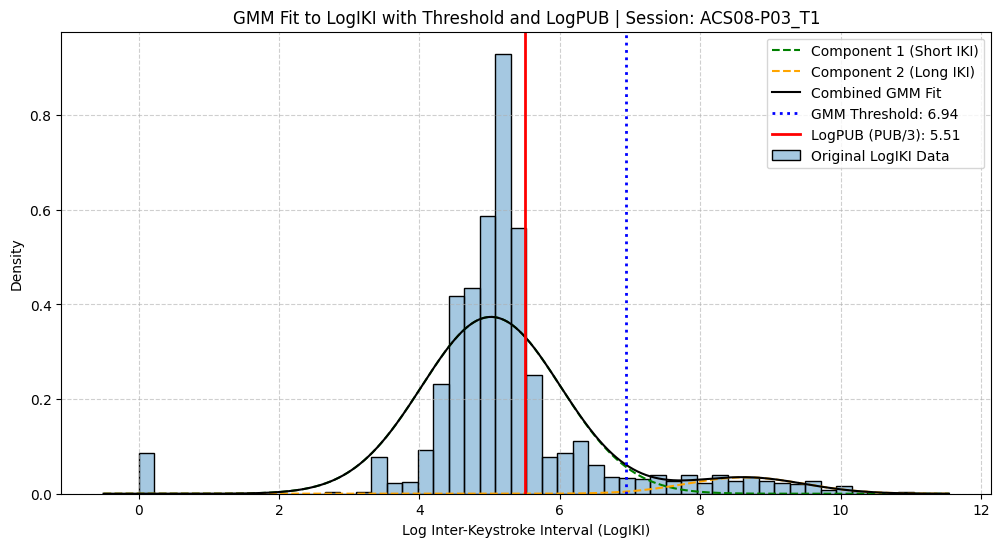

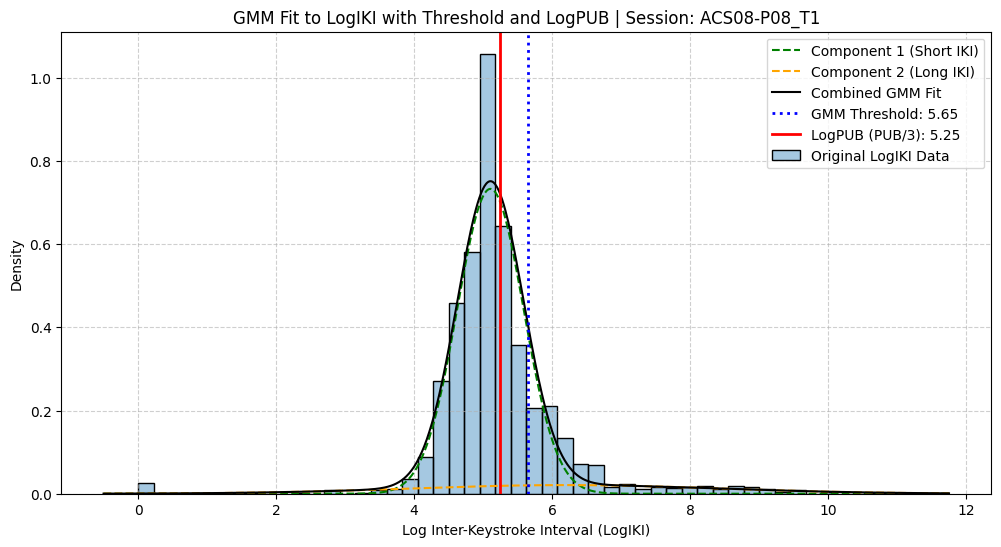

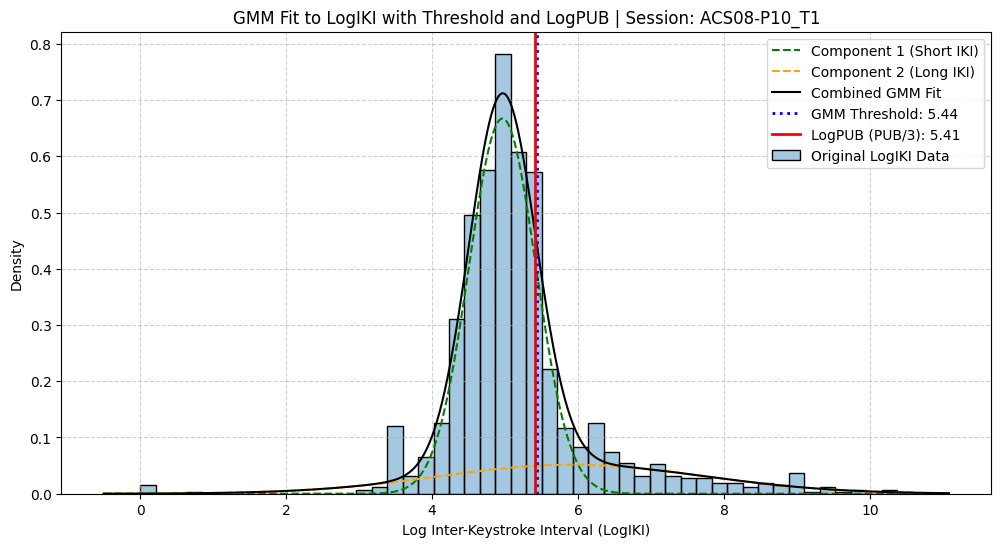

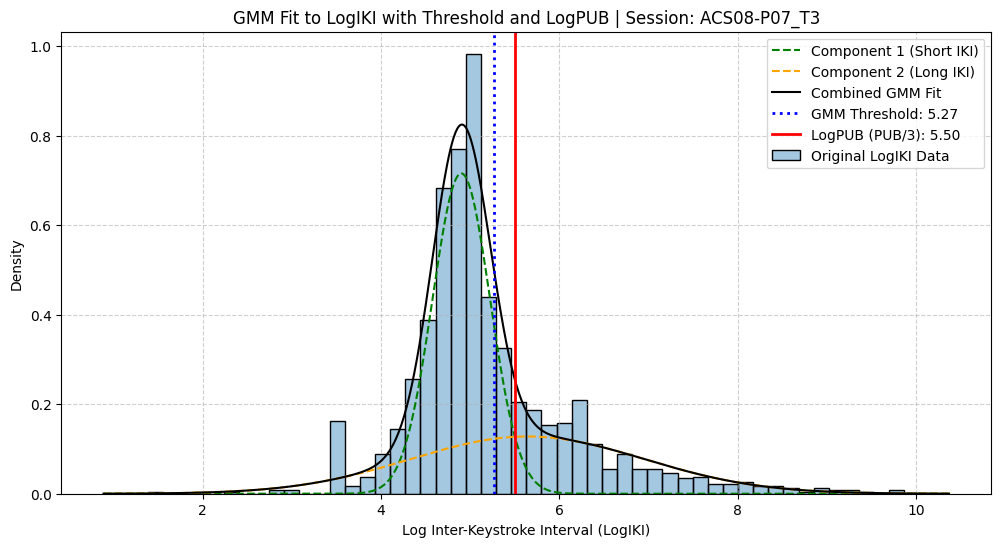

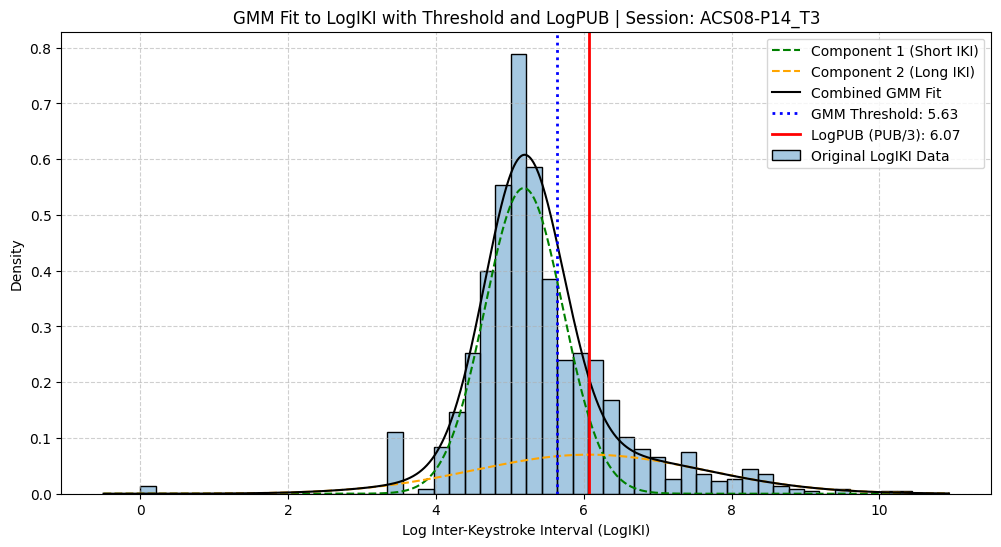

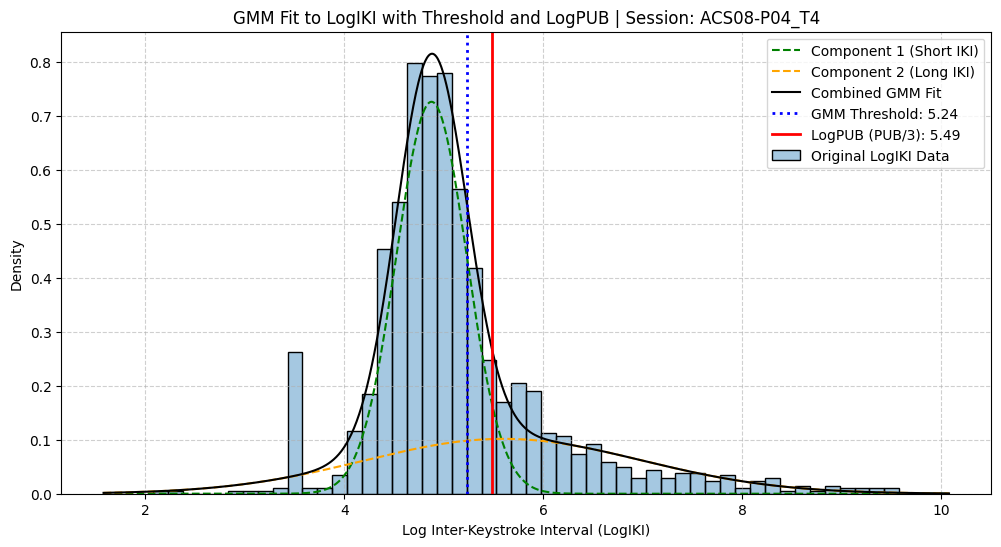

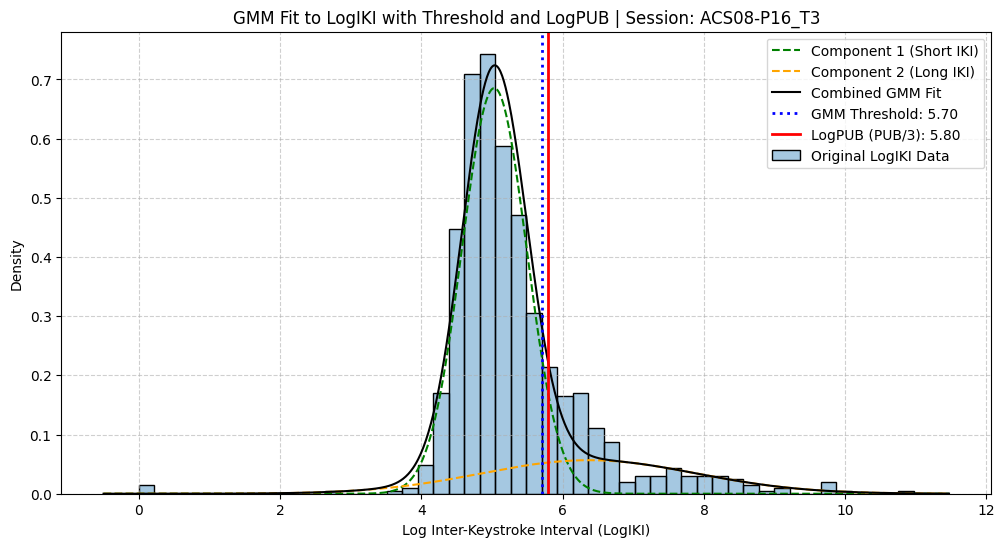

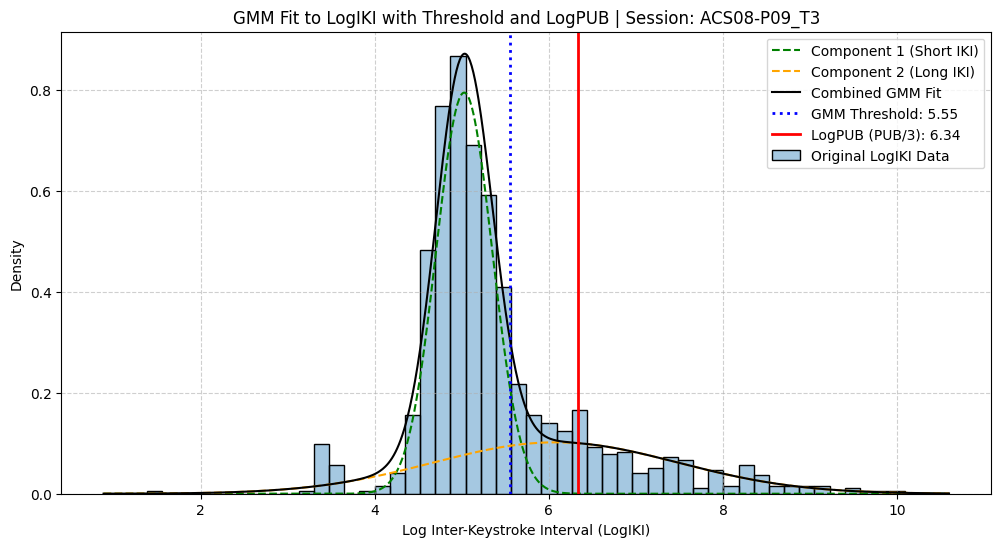

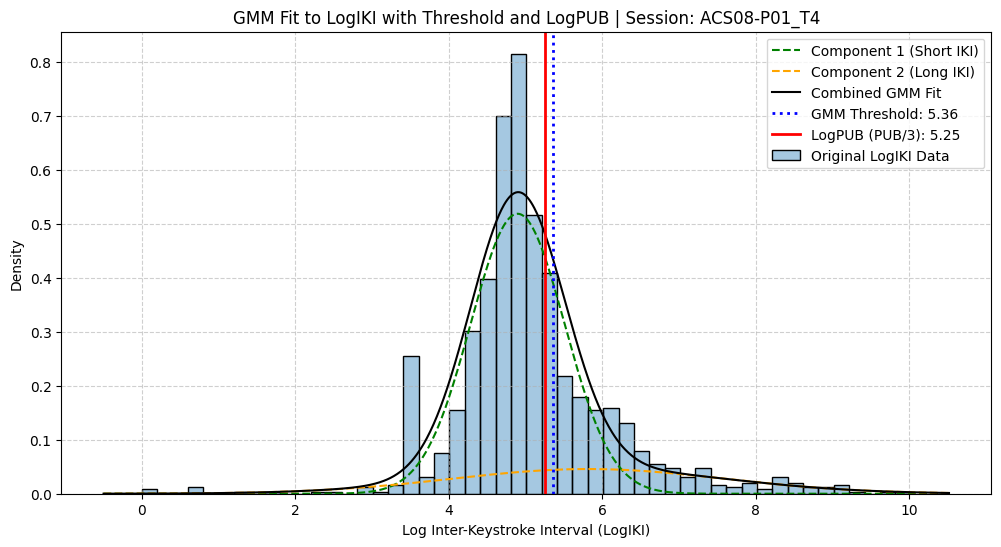

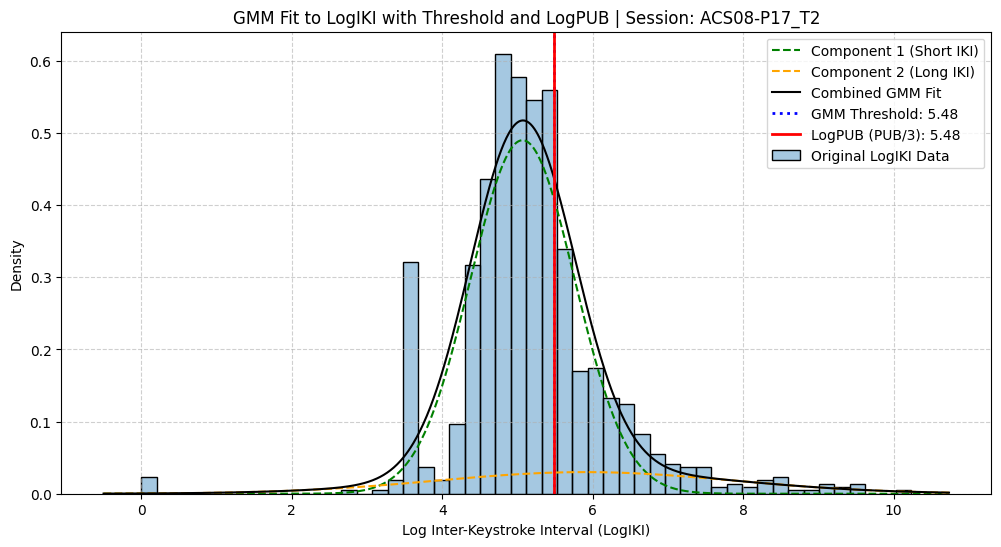

In [81]:
# Get the first 10 unique StudySession IDs that had a successful GMM fit when 2 distributions
sessions_to_plot = summary_df2.dropna(subset=['GMM_Threshold_LogIKI'])['StudySession'].unique()[:10]

print(f"\nGenerating GMM and LogIKI/LogPUB plots for the first {len(sessions_to_plot)} sessions.")

for session_id in sessions_to_plot:
    
    # 1. Get data for the specific session
    session_data = KDdf_iki[KDdf_iki['StudySession'] == session_id]
    log_iki_data_series = session_data['LogIKI']
    
    threshold_auto_inter = summary_df2[summary_df2['StudySession'] == session_id]['GMM_Threshold_LogIKI'].iloc[0]
    
    log_pub_value = AUdf_logpub_final[AUdf_logpub_final['StudySession'] == session_id]['LogPUB'].iloc[0]
    
    if pd.isna(threshold_auto_inter):
        print(f"Skipping plot for session {session_id}: GMM threshold is NaN.")
        continue
        
    # Check for empty data
    if log_iki_data_series.empty:
        print(f"Skipping plot for session {session_id}: No LogIKI data.")
        continue

    # 2. Fit the GMM again (to get the parameters for plotting)
    X = log_iki_data_series.values.reshape(-1, 1)
    n_components = 2
    
    # Add a check for sufficient data points before fitting
    if len(X) < n_components:
        print(f"Skipping plot for session {session_id}: Not enough data for N=2 GMM.")
        continue
        
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(X)
    
    means = gmm.means_.flatten()
    covariances = gmm.covariances_.flatten()
    weights = gmm.weights_.flatten()
    stds = np.sqrt(covariances)
    
    order = np.argsort(means)
    means, stds, weights = means[order], stds[order], weights[order]

    # 3. Plotting
    plt.figure(figsize=(12, 6))

    # Plot the original data histogram
    sns.histplot(data=session_data, x='LogIKI', bins=50, stat='density', alpha=0.4, label='Original LogIKI Data')

    # X-axis for plotting PDFs
    x_axis = np.linspace(log_iki_data_series.min() - 0.5, log_iki_data_series.max() + 0.5, 1000).reshape(-1, 1)
    
    # Plot the fitted Gaussian components
    colors = ['green', 'orange']
    labels = ['Component 1 (Short IKI)', 'Component 2 (Long IKI)']
    
    for i in range(n_components):
        # Scale PDF by its weight
        pdf = norm.pdf(x_axis, means[i], stds[i]) * weights[i]
        plt.plot(x_axis, pdf, color=colors[i], linestyle='--', label=labels[i])

    # Plot the combined GMM PDF
    total_pdf = gmm.score_samples(x_axis)
    plt.plot(x_axis, np.exp(total_pdf), color='black', label='Combined GMM Fit')

    # Draw the GMM threshold line
    plt.axvline(threshold_auto_inter, color='blue', linestyle=':', linewidth=2, label=f'GMM Threshold: {threshold_auto_inter:.2f}')

    # Draw the LogPUB line
    plt.axvline(log_pub_value, color='red', linestyle='-', linewidth=2, label=f'LogPUB (PUB/3): {log_pub_value:.2f}')


    plt.title(f'GMM Fit to LogIKI with Threshold and LogPUB | Session: {session_id}')
    plt.xlabel('Log Inter-Keystroke Interval (LogIKI)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

### 3 Components


Generating GMM (N=3) plots for the first 10 sessions.


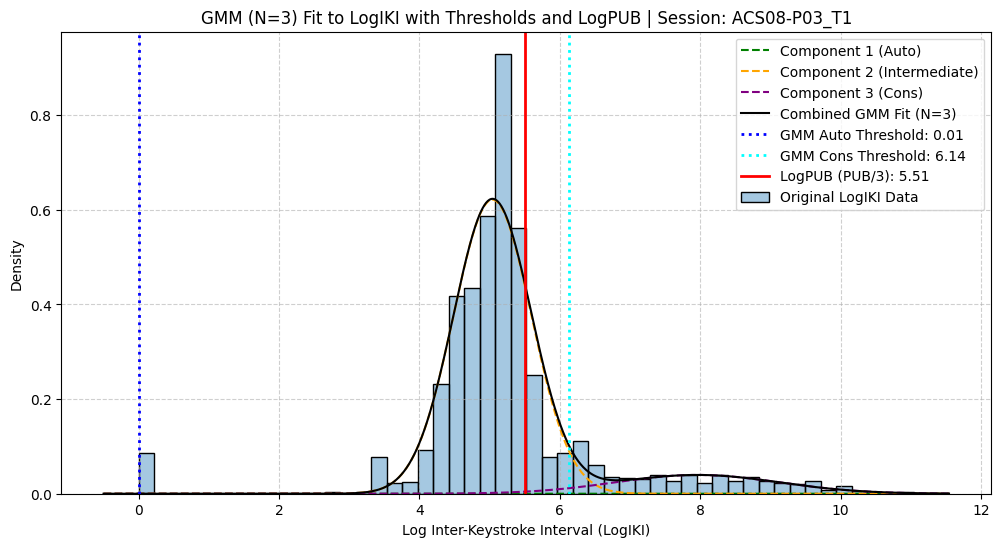

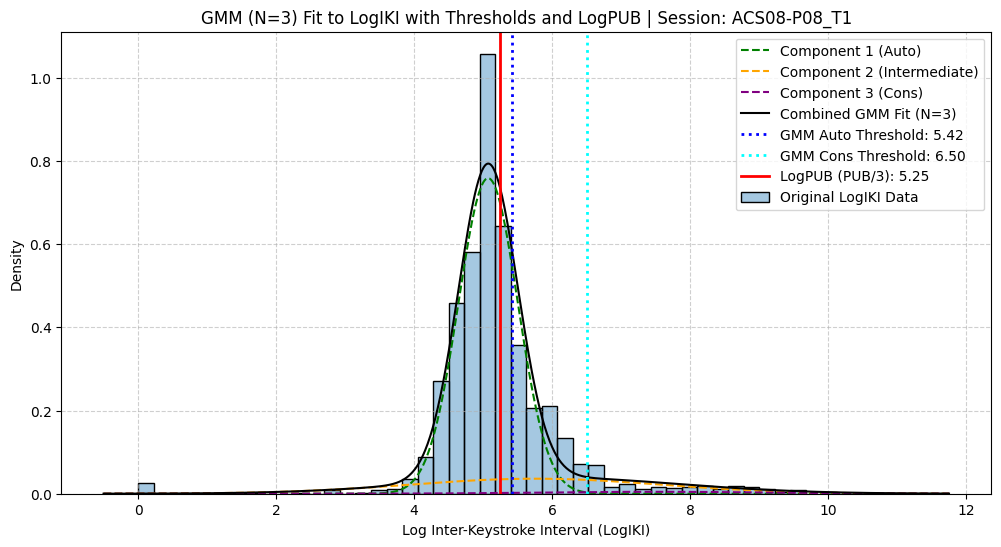

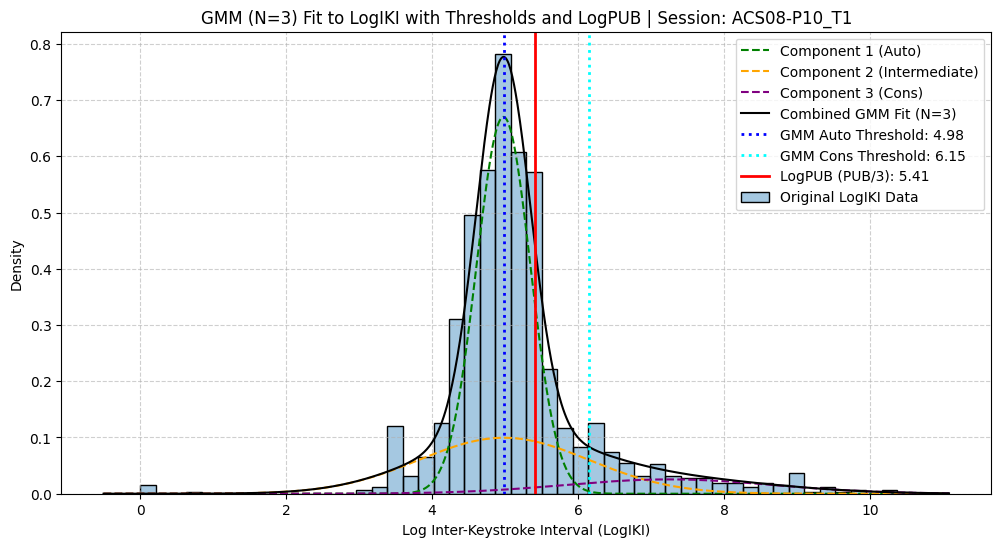

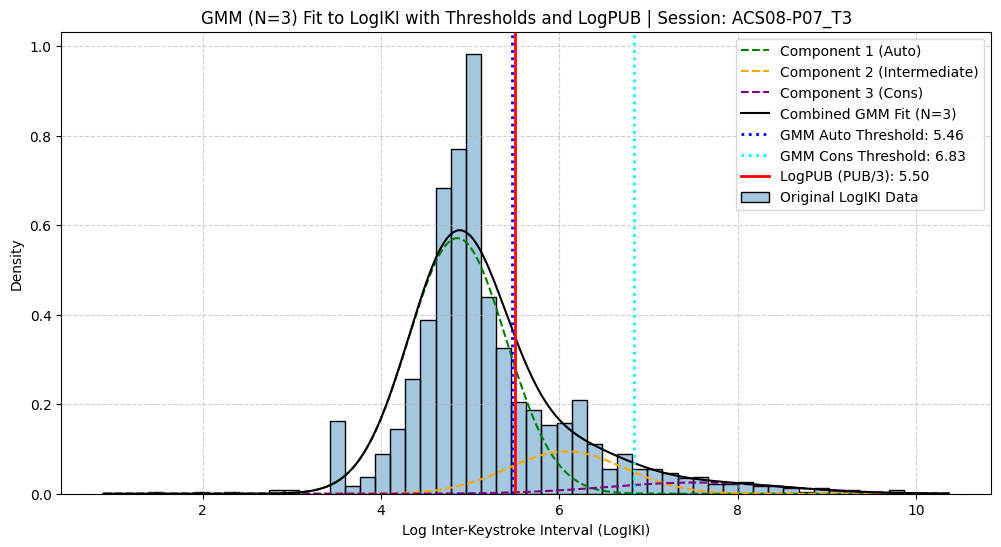

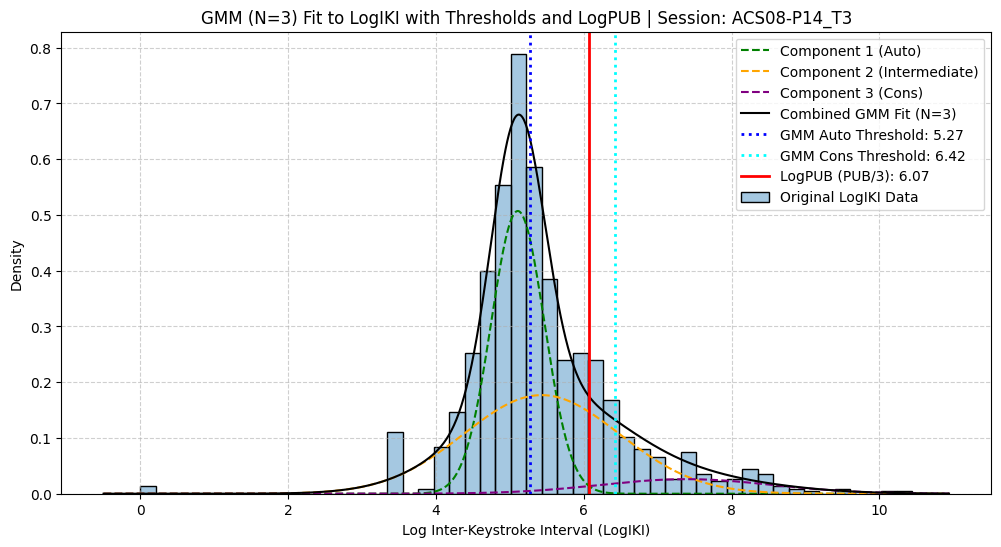

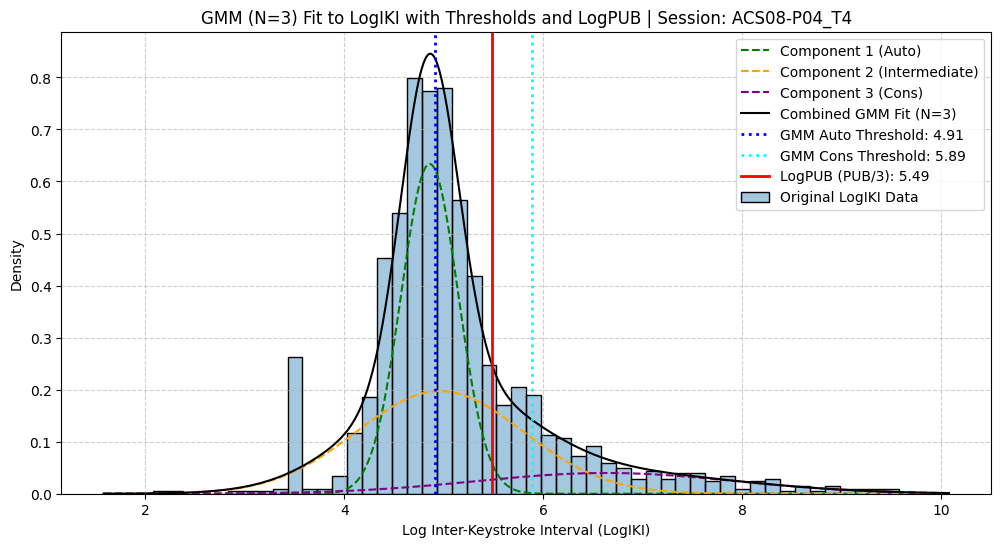

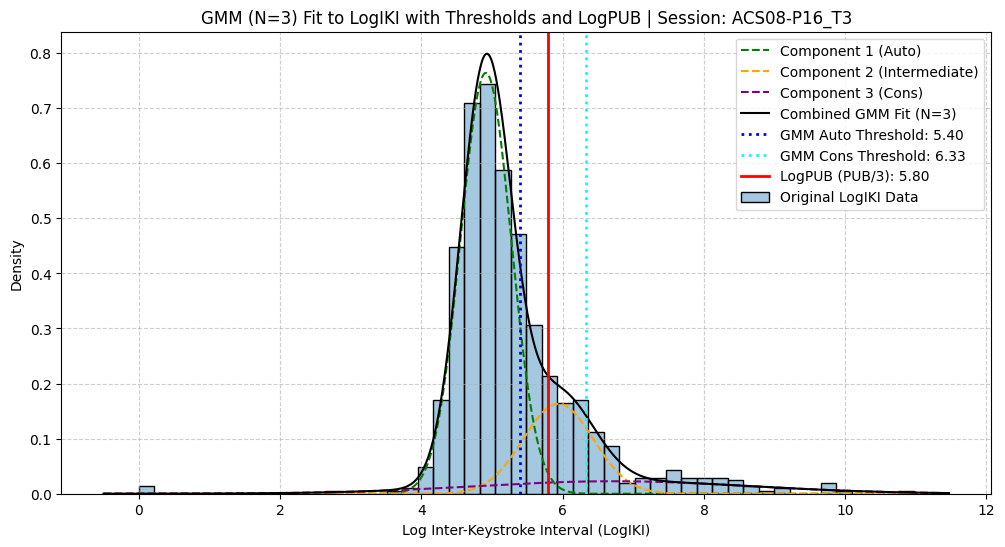

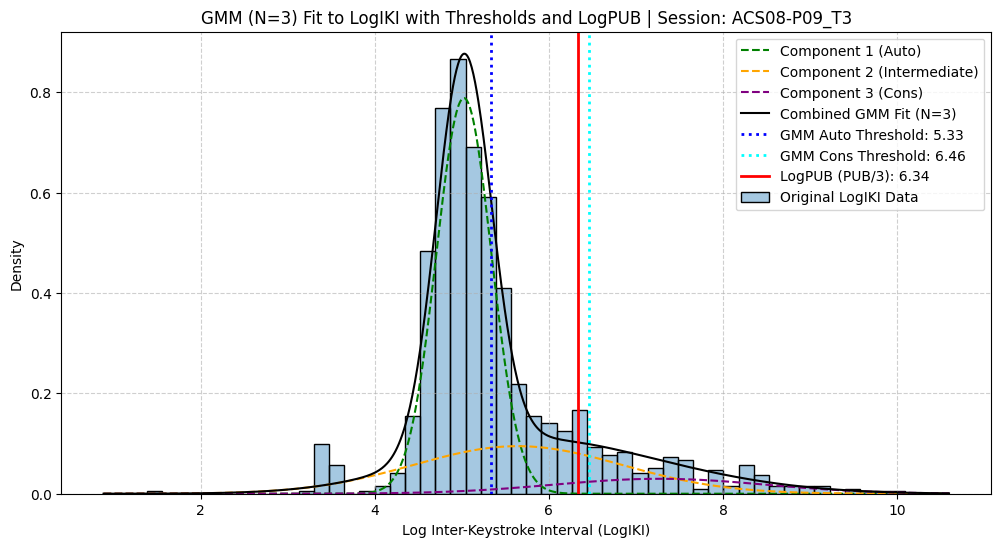

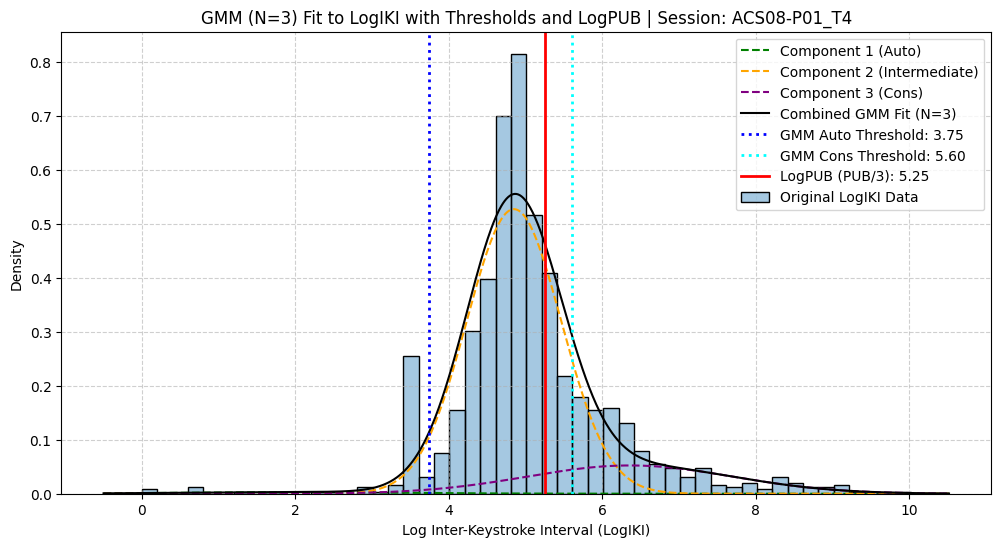

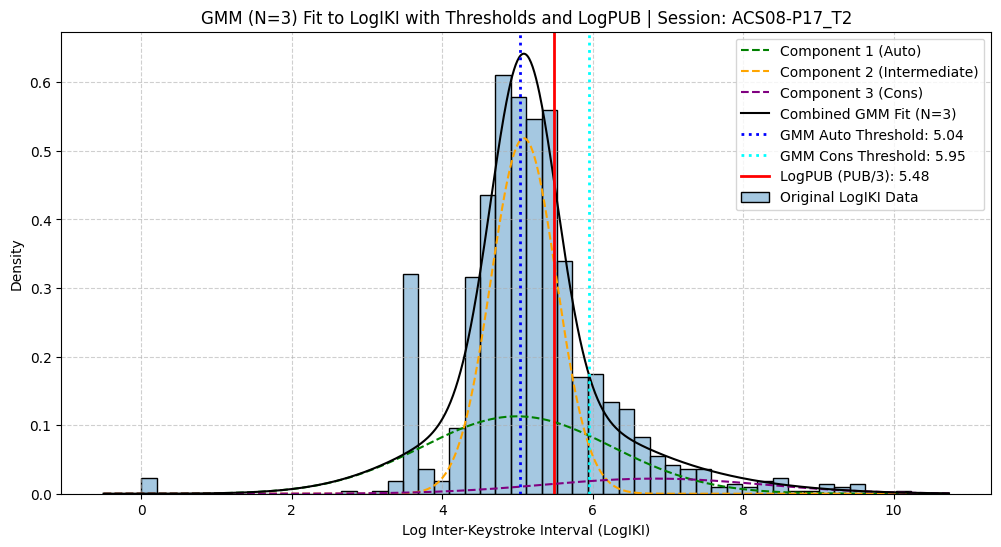

In [82]:
# ---  PLOTTING LOOP for 3components and 2 Thresholds ---

sessions_to_plot = summary_df3.dropna(subset=['gmm_iki_auto', 'gmm_iki_cons'])['StudySession'].unique()[:10]

print(f"\nGenerating GMM (N=3) plots for the first {len(sessions_to_plot)} sessions.")

for session_id in sessions_to_plot:
    
    # 1. Get LogIKI data for the specific session
    session_data = KDdf_iki[KDdf_iki['StudySession'] == session_id]
    log_iki_data_series = session_data['LogIKI']
    
    # Check for empty data
    if log_iki_data_series.empty:
        print(f"Skipping plot for session {session_id}: No LogIKI data.")
        continue

    # 2. Get this session's GMM thresholds from summary_df3
    session_summary = summary_df3[summary_df3['StudySession'] == session_id]
    if session_summary.empty:
        print(f"Skipping plot for session {session_id}: No threshold summary data found.")
        continue
        
    threshold_auto = session_summary['gmm_iki_auto'].iloc[0]
    threshold_cons = session_summary['gmm_iki_cons'].iloc[0]
    
    try:
        log_pub_value = AUdf_logpub_final[AUdf_logpub_final['StudySession'] == session_id]['LogPUB'].iloc[0]
    except IndexError:
        print(f"Skipping plot for session {session_id}: LogPUB value not found in AUdf_logpub_final.")
        continue

    
    # 3. Fit the GMM 
    X = log_iki_data_series.values.reshape(-1, 1)
    n_components = 3 # Ensure N=3 for this plot
    
    if len(X) < n_components:
        print(f"Skipping plot for session {session_id}: Not enough data ({len(X)} points) for N=3 GMM.")
        continue
        
    try:
        gmm = GaussianMixture(n_components=n_components, random_state=42)
        gmm.fit(X)
        
        means = gmm.means_.flatten()
        covariances = gmm.covariances_.flatten()
        weights = gmm.weights_.flatten()
        stds = np.sqrt(covariances)
        
        order = np.argsort(means)
        means, stds, weights = means[order], stds[order], weights[order]
        
        # Additional check in case GMM converges to fewer components despite enough data
        if len(means) < n_components:
             print(f"Skipping plot for session {session_id}: GMM converged to fewer than {n_components} components.")
             continue

    except ValueError as ve:
        print(f"Skipping plot for session {session_id}: GMM fitting error - {ve}")
        continue
    except Exception as e:
         print(f"Skipping plot for session {session_id}: Unexpected error during GMM fit - {e}")
         continue


    # 4. Plotting
    plt.figure(figsize=(12, 6))

    # Plot the original data histogram
    sns.histplot(data=session_data, x='LogIKI', bins=50, stat='density', alpha=0.4, label='Original LogIKI Data')

    # X-axis for plotting PDFs
    # Add small epsilon to prevent identical min/max if only one data point exists after dropna
    min_val = log_iki_data_series.min() - 0.5
    max_val = log_iki_data_series.max() + 0.5
    if min_val >= max_val: # Handle edge case
        min_val -= 0.1
        max_val += 0.1
    x_axis = np.linspace(min_val, max_val, 1000).reshape(-1, 1)
    
    # Plot the fitted Gaussian components
    colors = ['green', 'orange', 'purple'] 
    labels = ['Component 1 (Auto)', 'Component 2 (Intermediate)', 'Component 3 (Cons)'] 
    
    for i in range(n_components):
        pdf = norm.pdf(x_axis, means[i], stds[i]) * weights[i]
        plt.plot(x_axis, pdf, color=colors[i], linestyle='--', label=labels[i])

    # Plot the combined GMM PDF
    total_pdf = gmm.score_samples(x_axis)
    plt.plot(x_axis, np.exp(total_pdf), color='black', label='Combined GMM Fit (N=3)')

    # --- PLOT BOTH THRESHOLD LINES ---
    plt.axvline(threshold_auto, color='blue', linestyle=':', linewidth=2, label=f'GMM Auto Threshold: {threshold_auto:.2f}')
    plt.axvline(threshold_cons, color='cyan', linestyle=':', linewidth=2, label=f'GMM Cons Threshold: {threshold_cons:.2f}')

    # Draw the LogPUB line
    plt.axvline(log_pub_value, color='red', linestyle='-', linewidth=2, label=f'LogPUB (PUB/3): {log_pub_value:.2f}')


    plt.title(f'GMM (N=3) Fit to LogIKI with Thresholds and LogPUB | Session: {session_id}')
    plt.xlabel('Log Inter-Keystroke Interval (LogIKI)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show() 

## Quantile Calculation

In [84]:
print(f"Using KDdf_iki ({len(KDdf_iki)} rows) and AUdf_logpub_final ({len(AUdf_logpub_final)} rows).")

# --- Step 2: Merge the DataFrames ---
print("Merging DataFrames...")

# This broadcasts the single LogPUB value to all LogIKI rows for each session.
merged_df = pd.merge(KDdf_iki, AUdf_logpub, on='StudySession', how='inner')
print(f"Merge complete, resulting in {len(merged_df)} rows.")

Using KDdf_iki (564159 rows) and AUdf_logpub_final (490 rows).
Merging DataFrames...
Merge complete, resulting in 564159 rows.


Calculating quantile percentage for each session...
Calculated quantiles for 490 sessions.

Sample of session quantiles:
   StudySession  Quantile_Percent
0  ACS08-P01_T3         66.170763
1  ACS08-P01_T4         68.446215
2  ACS08-P02_T4         82.194245
3  ACS08-P03_T1         75.879087
4  ACS08-P03_T2         65.213523
Generating plot...


/tmp/ipykernel_4107343/3712471676.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_quantiles = merged_df.groupby('StudySession').apply(calculate_quantile_percent).reset_index(name='Quantile_Percent')


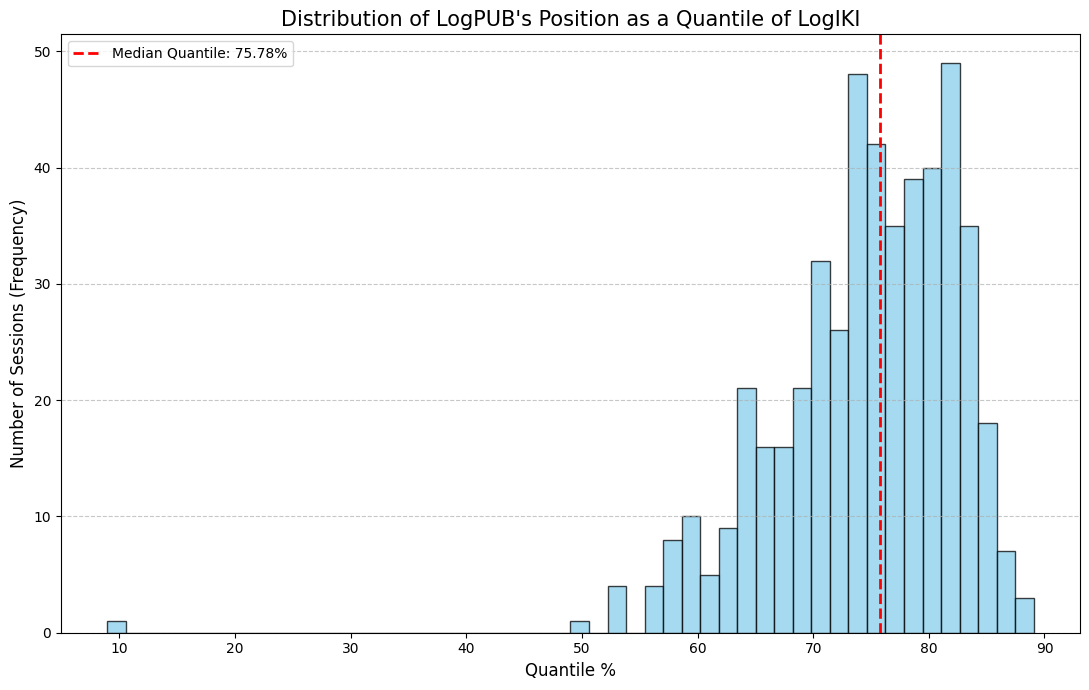

In [85]:
# ---  a function to calculate the quantile percentage ---
def calculate_quantile_percent(session_group):
    # Get the session's single LogPUB value
    log_pub_value = session_group['LogPUB'].iloc[0]
    
    if pd.isna(log_pub_value):
        return np.nan
        
    log_iki_values = session_group['LogIKI']
    
    # Count how many LogIKI values are below or equal to the LogPUB
    count_below = (log_iki_values <= log_pub_value).sum()
    total_count = len(log_iki_values)
    
    if total_count == 0:
        return np.nan
        
    # Calculate the percentage
    quantile_percent = (count_below / total_count) * 100
    return quantile_percent

# --- Apply the function to each session group ---
print("Calculating quantile percentage for each session...")
session_quantiles = merged_df.groupby('StudySession').apply(calculate_quantile_percent).reset_index(name='Quantile_Percent')

# Clean any sessions that might have failed
session_quantiles_clean = session_quantiles.dropna(subset=['Quantile_Percent'])
print(f"Calculated quantiles for {len(session_quantiles_clean)} sessions.")
print("\nSample of session quantiles:")
print(session_quantiles_clean.head())

# --- Plot the distribution of these quantile percentages ---
print("Generating plot...")
plt.figure(figsize=(11, 7))
# Plot a histogram. `bins=50` creates 50 bars.
plt.hist(session_quantiles_clean['Quantile_Percent'], bins=50, edgecolor='black', alpha=0.75, color='skyblue')

plt.title('Distribution of LogPUB\'s Position as a Quantile of LogIKI', fontsize=15)
plt.xlabel('Quantile %', fontsize=12)
plt.ylabel('Number of Sessions (Frequency)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a vertical line for the median, which is a good "desired value"
median_quantile = session_quantiles_clean['Quantile_Percent'].median()
plt.axvline(median_quantile, color='red', linestyle='dashed', linewidth=2, label=f'Median Quantile: {median_quantile:.2f}%')
plt.legend()

plt.tight_layout()
plt.show()

In [86]:
quantile_to_find = 0.75

print(f"Calculating {quantile_to_find*100:.0f}th percentile for each session...")

# Use groupby().quantile() to calculate the 75th percentile for each StudySession
KDdf_session = KDdf_iki.groupby('StudySession')['LogIKI'].quantile(quantile_to_find).reset_index()

# Rename the 'LogIKI' column (which now holds the quantile value) to 'Quantile_iki'
KDdf_session = KDdf_session.rename(columns={'LogIKI': 'Quantile_iki'})

print(f"Calculation complete for {len(KDdf_session)} sessions.")
print(KDdf_session.head())

Calculating 75th percentile for each session...
Calculation complete for 490 sessions.
   StudySession  Quantile_iki
0  ACS08-P01_T3      5.488938
1  ACS08-P01_T4      5.429346
2  ACS08-P02_T4      5.614946
3  ACS08-P03_T1      5.484797
4  ACS08-P03_T2      5.510398


In [87]:
final1 = pd.merge(AUdf_logpub_final, summary_df2, on='StudySession', how='inner') 
final2 = pd.merge(final1, summary_df3, on='StudySession', how='inner')
final = pd.merge(final2, KDdf_session, on='StudySession', how='inner')
final

,StudySession,LogPUB,LogKBI,GMM_Threshold_LogIKI,gmm_iki_auto,gmm_iki_cons,Quantile_iki
0,ACS08-P03_T1,5.505332,5.123964,6.938764,0.009738,6.138073,5.484797
1,ACS08-P08_T1,5.247024,5.087596,5.650591,5.418477,6.503250,5.488938
2,ACS08-P10_T1,5.407172,4.976734,5.440663,4.980448,6.148626,5.416100
3,ACS08-P07_T3,5.497168,4.990433,5.269511,5.462882,6.831987,5.535362
4,ACS08-P14_T3,6.073045,5.159055,5.631015,5.267438,6.420639,5.874931
...,...,...,...,...,...,...,...
485,ST19-P34_T3,5.840642,5.049856,5.585835,5.463106,6.337677,5.384495
486,ST19-P29_T4,6.115892,5.147494,5.551169,5.218943,6.217421,5.693732
487,ST19-P14_T3,5.793014,5.231109,5.740555,5.566167,6.225588,5.793014
488,ST19-P30_T3,6.182085,5.389072,5.985260,5.753756,6.663567,5.926926


## Final Correlation & Data Export

In [88]:
final[["LogKBI","LogPUB","GMM_Threshold_LogIKI",'gmm_iki_auto',	'gmm_iki_cons','Quantile_iki']].corr()

,LogKBI,LogPUB,GMM_Threshold_LogIKI,gmm_iki_auto,gmm_iki_cons,Quantile_iki
LogKBI,1.000000,0.800586,0.003830,-0.080606,0.565944,0.929476
LogPUB,0.800586,1.000000,0.046285,-0.027028,0.613597,0.860254
GMM_Threshold_LogIKI,0.003830,0.046285,1.000000,0.298464,0.237387,0.064274
gmm_iki_auto,-0.080606,-0.027028,0.298464,1.000000,0.336767,-0.048625
gmm_iki_cons,0.565944,0.613597,0.237387,0.336767,1.000000,0.640018
Quantile_iki,0.929476,0.860254,0.064274,-0.048625,0.640018,1.000000


In [51]:
# Create the DataFrame with only the desired columns
data_to_save = final[["StudySession","LogKBI", "LogPUB", "GMM_Threshold_LogIKI", "gmm_iki_auto", "gmm_iki_cons", "Quantile_iki"]]

# Save as CSV
data_to_save.to_csv('Threshold_LogIKI.csv', index=False) 